# 02 — XGBoost Rent Prediction + SHAP Explainability
## MietOptimal / RentSignal

**Input:** `data/processed/listings_clean.parquet`  
**Output:** `models/xgboost_rent.joblib`, `models/shap_explainer.joblib`, `models/feature_encoder.joblib`, `models/training_report.md`

### Pipeline
1. Load clean data
2. Prepare features: encode categoricals, split train/test
3. Train XGBoost with hyperparameter tuning
4. Evaluate: R², RMSE, MAE — compare vs linear baseline
5. SHAP analysis: global importance + waterfall plots for demo apartments
6. Save all artifacts

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import shap

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

%matplotlib inline

MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\danny\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\danny\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\danny\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\danny\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.1.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\danny\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\danny\anaconda3\Lib\site-packages\traitlets\config\application.py", line 992, in launch_instance
    app.start()
  File "c:\Users\danny\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "c:\Users\danny\anaconda3\Lib\site-packa

AttributeError: _ARRAY_API not found

## 1. Load Clean Data

In [2]:
df = pd.read_parquet("../data/processed/listings_clean.parquet")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nTarget (rent_sqm) stats:")
print(df["rent_sqm"].describe().to_string())

Loaded: 10,275 rows × 27 columns

Target (rent_sqm) stats:
count    10275.000000
mean        14.055061
std          5.099333
min          5.100200
25%         10.227177
50%         13.150000
75%         17.000000
max         40.000000


## 2. Feature Preparation

**Target:** `rent_sqm` (€/m² cold rent) — predicting per-sqm rent is more generalizable than absolute rent.

**Features:**
- Numeric: livingSpace, noRooms, yearConstructed, floor, numberOfFloors, thermalChar, sqm_per_room
- Binary: balcony, hasKitchen, lift, cellar, garden, newlyConst
- Categorical (ordinal-encoded): condition, interiorQual, typeOfFlat, heatingType, building_era, bezirk

In [3]:
# Define feature groups
NUMERIC_FEATURES = [
    "livingSpace", "noRooms", "yearConstructed", "floor",
    "numberOfFloors", "thermalChar", "sqm_per_room",
]

BINARY_FEATURES = [
    "balcony", "hasKitchen", "lift", "cellar", "garden", "newlyConst",
]

CATEGORICAL_FEATURES = [
    "condition", "interiorQual", "typeOfFlat", "heatingType",
    "building_era", "bezirk",
]

TARGET = "rent_sqm"

# Fill remaining NaN in yearConstructed with median for the model
df["yearConstructed"] = df["yearConstructed"].fillna(df["yearConstructed"].median())

# Encode categoricals with OrdinalEncoder (XGBoost handles ordinals fine)
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df[CATEGORICAL_FEATURES] = enc.fit_transform(df[CATEGORICAL_FEATURES].astype(str))

# Convert booleans to int
for col in BINARY_FEATURES:
    df[col] = df[col].astype(int)

ALL_FEATURES = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES

X = df[ALL_FEATURES]
y = df[TARGET]

print(f"Features: {len(ALL_FEATURES)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeature list: {ALL_FEATURES}")

Features: 19
X shape: (10275, 19)
y shape: (10275,)

Feature list: ['livingSpace', 'noRooms', 'yearConstructed', 'floor', 'numberOfFloors', 'thermalChar', 'sqm_per_room', 'balcony', 'hasKitchen', 'lift', 'cellar', 'garden', 'newlyConst', 'condition', 'interiorQual', 'typeOfFlat', 'heatingType', 'building_era', 'bezirk']


In [4]:
# Train/test split (80/20, stratified by bezirk to ensure geographic balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Train rent_sqm mean: {y_train.mean():.2f} | Test: {y_test.mean():.2f}")

Train: 8,220 | Test: 2,055
Train rent_sqm mean: 14.01 | Test: 14.23


## 3. Baseline: Linear Regression

Establishes the "hedonic pricing" baseline that XGBoost should beat.

In [5]:
# Ridge regression as linear baseline (regularized to handle collinearity)
lr = Ridge(alpha=1.0)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)

print("=== Linear Baseline (Ridge) ===")
print(f"R²:   {lr_r2:.4f}")
print(f"RMSE: {lr_rmse:.2f} €/m²")
print(f"MAE:  {lr_mae:.2f} €/m²")

=== Linear Baseline (Ridge) ===
R²:   0.3431
RMSE: 4.26 €/m²
MAE:  3.20 €/m²


## 4. XGBoost: Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import KFold, cross_validate

# Grid search over key hyperparameters
param_grid = {
    "n_estimators": [200, 500, 800],
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8],
    "colsample_bytree": [0.8],
    "min_child_weight": [3, 5],
}

xgb_base = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist",
)

grid = GridSearchCV(
    xgb_base,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1,
    refit=True,
)

grid.fit(X_train, y_train)

print(f"\nBest params: {grid.best_params_}")
print(f"Best CV R²: {grid.best_score_:.4f}")

## 5. Evaluate on Test Set

In [ ]:
model = grid.best_estimator_
y_pred = model.predict(X_test)

xgb_r2 = r2_score(y_test, y_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
xgb_mae = mean_absolute_error(y_test, y_pred)

print("=" * 50)
print("MODEL COMPARISON — Test Set")
print("=" * 50)
print(f"{'Metric':<12} {'Ridge (linear)':<18} {'XGBoost':<18} {'Improvement'}")
print("-" * 50)
print(f"{'R²':<12} {lr_r2:<18.4f} {xgb_r2:<18.4f} {xgb_r2 - lr_r2:+.4f}")
print(f"{'RMSE':<12} {lr_rmse:<18.2f} {xgb_rmse:<18.2f} {xgb_rmse - lr_rmse:+.2f}")
print(f"{'MAE':<12} {lr_mae:<18.2f} {xgb_mae:<18.2f} {xgb_mae - lr_mae:+.2f}")
print("=" * 50)
print(f"\nXGBoost reduces RMSE by {(1 - xgb_rmse/lr_rmse)*100:.1f}% vs linear baseline")

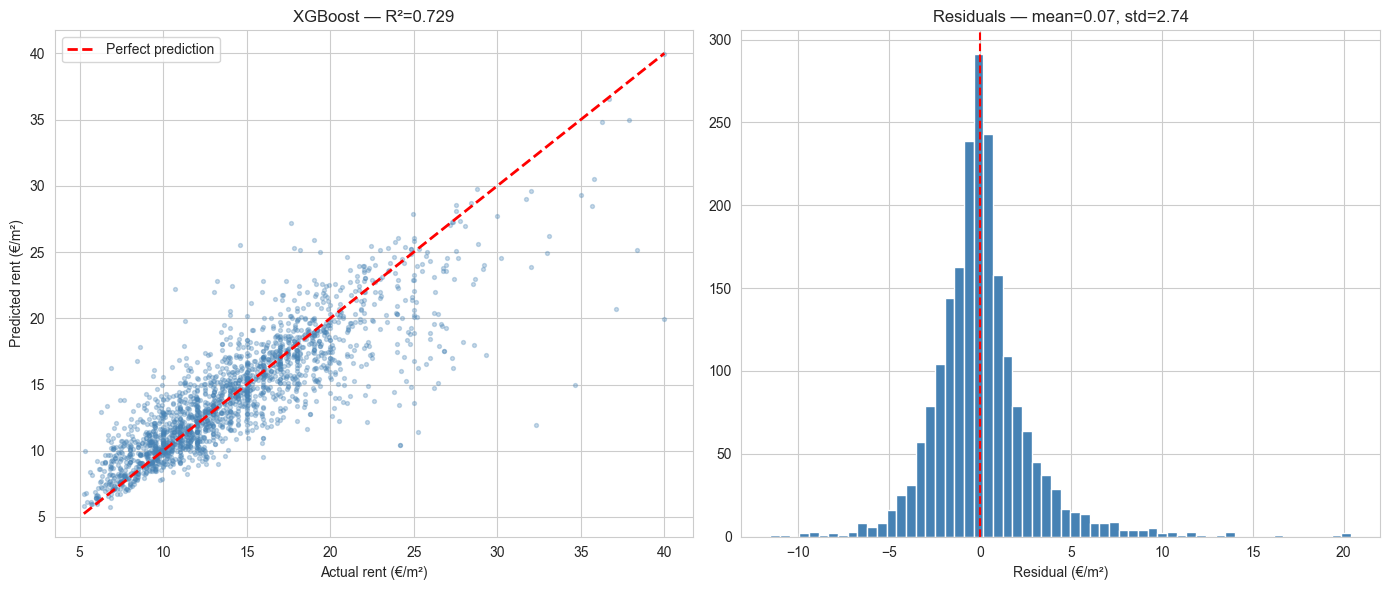

In [10]:
# Predicted vs Actual scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost
axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color="steelblue")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             "r--", lw=2, label="Perfect prediction")
axes[0].set_xlabel("Actual rent (€/m²)")
axes[0].set_ylabel("Predicted rent (€/m²)")
axes[0].set_title(f"XGBoost — R²={xgb_r2:.3f}")
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].hist(residuals, bins=60, edgecolor="white", color="steelblue")
axes[1].axvline(0, color="red", ls="--")
axes[1].set_xlabel("Residual (€/m²)")
axes[1].set_title(f"Residuals — mean={residuals.mean():.2f}, std={residuals.std():.2f}")

plt.tight_layout()
plt.show()

## 6. SHAP Analysis

In [11]:
# Create SHAP explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values on test set (sample for speed if large)
shap_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
shap_values = explainer(shap_sample)

print(f"SHAP values computed for {len(shap_sample)} samples")

SHAP values computed for 1000 samples


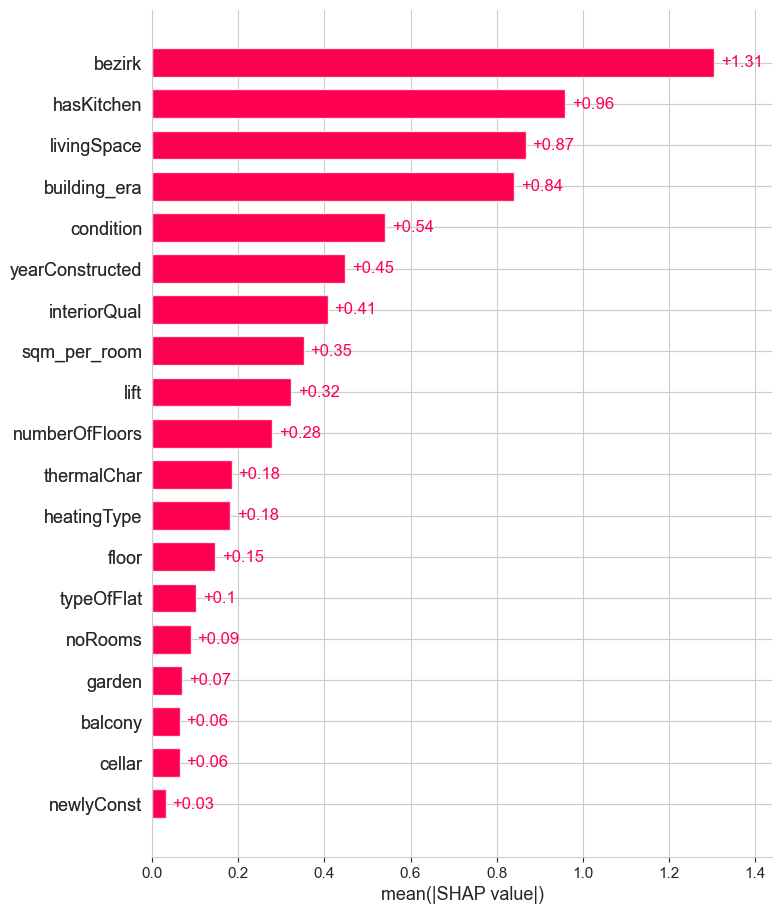

In [12]:
# Global feature importance (mean |SHAP|)
shap.plots.bar(shap_values, max_display=20, show=True)

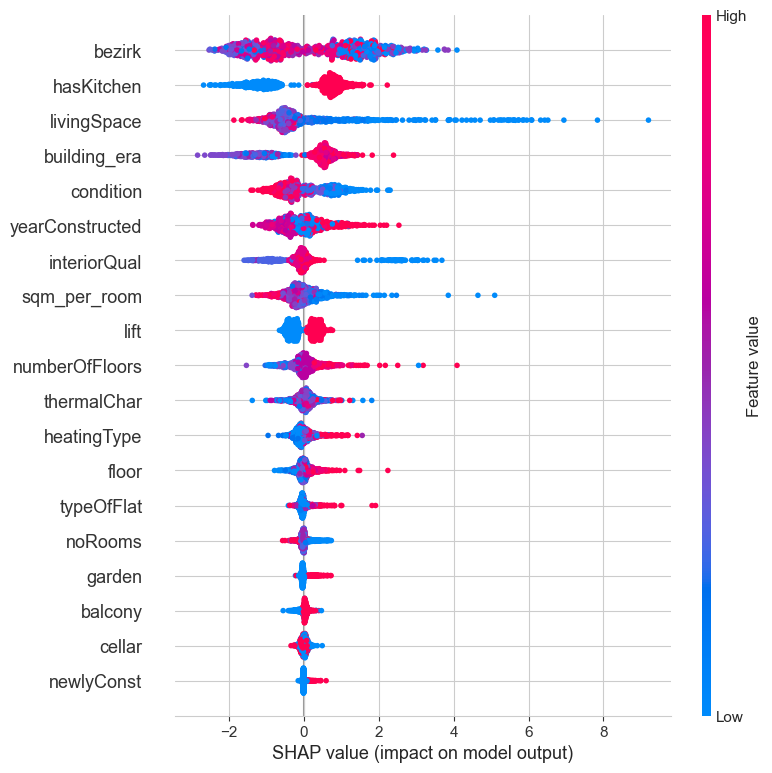

In [13]:
# Beeswarm plot — feature impact direction + magnitude
shap.plots.beeswarm(shap_values, max_display=20, show=True)

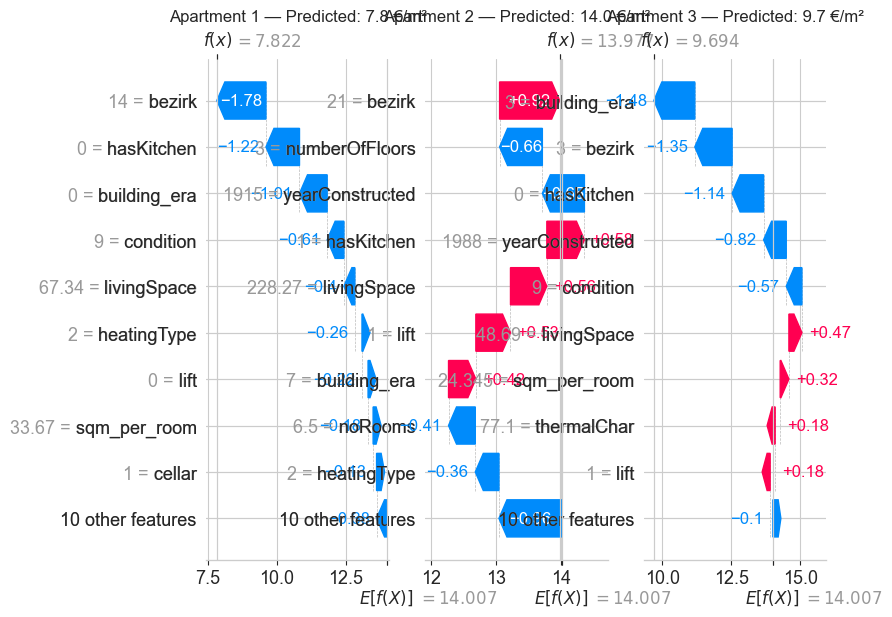

In [14]:
# Waterfall plot for individual predictions (demo-style)
# Show 3 example apartments from test set
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    shap.plots.waterfall(shap_values[i], max_display=10, show=False)
    plt.title(f"Apartment {i+1} — Predicted: {model.predict(shap_sample.iloc[[i]])[0]:.1f} €/m²")

plt.tight_layout()
plt.show()

## 7. Save Artifacts

In [15]:
# Save model
joblib.dump(model, MODELS_DIR / "xgboost_rent.joblib")
print(f"Saved: {MODELS_DIR / 'xgboost_rent.joblib'}")

# Save SHAP explainer
joblib.dump(explainer, MODELS_DIR / "shap_explainer.joblib")
print(f"Saved: {MODELS_DIR / 'shap_explainer.joblib'}")

# Save encoder (needed to transform new inputs at inference time)
joblib.dump(enc, MODELS_DIR / "feature_encoder.joblib")
print(f"Saved: {MODELS_DIR / 'feature_encoder.joblib'}")

# Save feature list and config for reproducibility
import json
model_config = {
    "target": TARGET,
    "features": ALL_FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "binary_features": BINARY_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "best_params": grid.best_params_,
    "train_size": len(X_train),
    "test_size": len(X_test),
}
with open(MODELS_DIR / "model_config.json", "w") as f:
    json.dump(model_config, f, indent=2)
print(f"Saved: {MODELS_DIR / 'model_config.json'}")

Saved: ..\models\xgboost_rent.joblib
Saved: ..\models\shap_explainer.joblib
Saved: ..\models\feature_encoder.joblib
Saved: ..\models\model_config.json


## 8. Training Report

In [16]:
# Generate training report markdown
from datetime import datetime

report = f"""# XGBoost Rent Prediction — Training Report
## Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}

### Dataset
- Source: Kaggle ImmoScout24 (Berlin subset)
- Training samples: {len(X_train):,}
- Test samples: {len(X_test):,}
- Features: {len(ALL_FEATURES)}
- Target: rent per m² (baseRent / livingSpace)

### Model Comparison

| Metric | Ridge (linear) | XGBoost | Improvement |
|--------|---------------|---------|-------------|
| R²     | {lr_r2:.4f}   | {xgb_r2:.4f} | {xgb_r2 - lr_r2:+.4f} |
| RMSE   | {lr_rmse:.2f} €/m² | {xgb_rmse:.2f} €/m² | {(1 - xgb_rmse/lr_rmse)*100:.1f}% reduction |
| MAE    | {lr_mae:.2f} €/m² | {xgb_mae:.2f} €/m² | {(1 - xgb_mae/lr_mae)*100:.1f}% reduction |

### Best Hyperparameters
{json.dumps(grid.best_params_, indent=2)}

### Features Used
**Numeric:** {', '.join(NUMERIC_FEATURES)}
**Binary:** {', '.join(BINARY_FEATURES)}
**Categorical:** {', '.join(CATEGORICAL_FEATURES)}

### Notes
- Data vintage: 2018-2019 (will need price adjustment for 2024-2025 levels)
- No spatial features yet — will be added after Task 4 (satellite pipeline)
- Categorical features ordinal-encoded (XGBoost handles this natively)
"""

with open(MODELS_DIR / "training_report.md", "w") as f:
    f.write(report)

print(report)
print(f"\nSaved: {MODELS_DIR / 'training_report.md'}")

# XGBoost Rent Prediction — Training Report
## Generated: 2026-03-15 10:02

### Dataset
- Source: Kaggle ImmoScout24 (Berlin subset)
- Training samples: 8,220
- Test samples: 2,055
- Features: 19
- Target: rent per m² (baseRent / livingSpace)

### Model Comparison

| Metric | Ridge (linear) | XGBoost | Improvement |
|--------|---------------|---------|-------------|
| R²     | 0.3431   | 0.7290 | +0.3859 |
| RMSE   | 4.26 €/m² | 2.74 €/m² | 35.8% reduction |
| MAE    | 3.20 €/m² | 1.82 €/m² | 43.0% reduction |

### Best Hyperparameters
{
  "colsample_bytree": 0.8,
  "learning_rate": 0.05,
  "max_depth": 8,
  "min_child_weight": 3,
  "n_estimators": 500,
  "subsample": 0.8
}

### Features Used
**Numeric:** livingSpace, noRooms, yearConstructed, floor, numberOfFloors, thermalChar, sqm_per_room
**Binary:** balcony, hasKitchen, lift, cellar, garden, newlyConst
**Categorical:** condition, interiorQual, typeOfFlat, heatingType, building_era, bezirk

### Notes
- Data vintage: 2018-2019 (will 